# RNA-seq analysis

Data processed with nf-core pipeline (Salmon mapper).

Then performed differential expression analysis with DESeq2.

In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
import scipy.stats
import os
from adjustText import adjust_text
import matplotlib.patheffects as PathEffects
import warnings
warnings.filterwarnings('ignore')
plt.rc('font', family='Helvetica')

In [2]:
tx2gene = pd.read_csv("../../source_data/11_rnaseq_data_deseq2/tx2gene.tsv", sep='\t')

gene_name_dict = dict(zip(tx2gene['gene_id'], tx2gene['gene_name']))

In [3]:
samp_dict = {'L156F_24hrs_vs_L156F_no_drug':'../../source_data/11_rnaseq_data_deseq2/L156F_24hours_vs_L156F_no_drug.csv',
'L156F_48hrs_vs_L156F_no_drug':'../../source_data/11_rnaseq_data_deseq2/L156F_48hours_vs_L156F_no_drug.csv',
'NT_24hrs_vs_NT_no_drug':'../../source_data/11_rnaseq_data_deseq2/NT_24hours_vs_NT_no_drug.csv',
'NT_48hrs_vs_NT_no_drug':'../../source_data/11_rnaseq_data_deseq2/NT_48hours_vs_NT_no_drug.csv',
'L156F_no_drug_vs_NT_no_drug':'../../source_data/11_rnaseq_data_deseq2/L156F_no_drug_vs_NT_no_drug.csv'}

samples = list(samp_dict.keys())

tx2gene = pd.read_csv("../../source_data/11_rnaseq_data_deseq2/tx2gene.tsv", sep='\t')
gene_name_dict = dict(zip(tx2gene['gene_id'], tx2gene['gene_name']))

filtered_holder = []
unfiltered_holder = []

basemean_cutoff = 20

for i in samples:

    file = samp_dict[i]
    df = pd.read_csv(file).rename(columns={'Unnamed: 0':'gene_id'})
    df['gene_name'] = [gene_name_dict[i] for i in df['gene_id']]

    df2 = df[df['baseMean']>=basemean_cutoff]
    df2 = df2.set_index('gene_name')

    print(f'{len(df2)}/{len(df)}')

    filtered_holder.append(df2)
    unfiltered_holder.append(df)

filtered_dict = dict(zip(samples, filtered_holder))
unfiltered_dict = dict(zip(samples, unfiltered_holder))


sample_names = ['L156F KI-CDK9d-32\n24 hrs vs. No Drug',
                'L156F KI-CDK9d-32\n48 hrs vs. No Drug',
                'NT gRNA KI-CDK9d-32\n24 hrs vs. No Drug',
                'NT gRNA KI-CDK9d-32\n48 hrs vs. No Drug',
                'L156F vs. NT gRNA\n(No Drug)']

samp_name_dict = dict(zip(samples, sample_names))

15737/35965
15794/36094
16097/38233
15975/37525
15672/35867


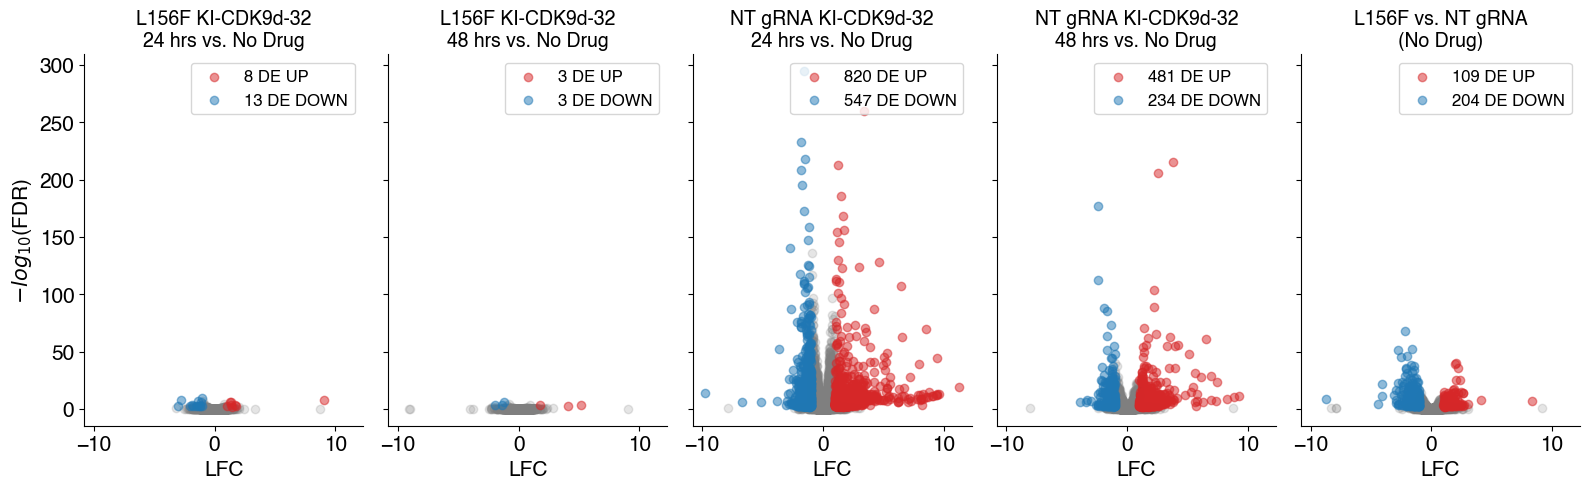

In [ ]:
fig, ax = plt.subplots(1,5, figsize=(16,5), sharey=True, sharex=True)


for i in range(5):
    ax[i].spines[['top', 'right']].set_visible(False)
    ax[i].tick_params(axis='x', which='major', labelsize=15)
    ax[i].tick_params(axis='y', which='major', labelsize=15)
    ax[i].set_xlabel('LFC', fontsize=15)

ax[0].set_ylabel('$-log_{10}$(FDR)', fontsize=15)

for i, k in enumerate(samples):
    a = filtered_dict[k].reset_index()
    subset_low = a[(a['log2FoldChange']<=-1) & (a['padj']<=.01)]
    #subset_high = a[a['gene_name'].isin(associated_genes)]
    subset_high = a[(a['log2FoldChange']>=1) & (a['padj']<=.01)]

    idx_de = pd.concat((subset_low, subset_high))

    a_no_change = a.drop(list(idx_de.index), axis=0)
    
    
    ax[i].scatter(a_no_change['log2FoldChange'], -np.log10(a_no_change['padj']), color='tab:grey', alpha=.2, rasterized=True)
    ax[i].scatter(subset_high['log2FoldChange'], -np.log10(subset_high['padj']), color='tab:red', label=f'{len(subset_high)} DE UP', alpha=.5, rasterized=True)
    ax[i].scatter(subset_low['log2FoldChange'], -np.log10(subset_low['padj']), color='tab:blue', label=f'{len(subset_low)} DE DOWN', alpha=.5, rasterized=True)

    ax[i].legend(fontsize=12)

    ax[i].set_title(samp_name_dict[k], fontsize=14)

    
fig.tight_layout()
#fig.savefig('../../figures/RNA_seq_comp.pdf',dpi=300, transparent=True)

In [3]:
#df = pd.read_csv('rnaseq_data_deseq2/NT_24hours_vs_NT_no_drug.csv').rename(columns={'Unnamed: 0':'gene_id'})

df = pd.read_csv('../../source_data/11_rnaseq_data_deseq2/L156F_no_drug_vs_NT_no_drug.csv').rename(columns={'Unnamed: 0':'gene_id'})


df['gene_name'] = [gene_name_dict[i] for i in df['gene_id']]



df2 = df[df['baseMean']>=50]

df2 = df2.set_index('gene_name')

In [4]:
df2.sort_values(by='padj', ascending=True)[:40]

,gene_id,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_name,,,,,,,
TNS1,ENSG00000079308.21,1999.362624,-2.222871,0.123384,-18.015855,1.463041e-72,2.765440e-68
CCDC80,ENSG00000091986.16,7845.887075,-1.640915,0.103159,-15.906610,5.701816e-57,5.388786e-53
USH1C,ENSG00000006611.17,428.185925,-2.757662,0.175085,-15.750429,6.821644e-56,4.298090e-52
COL5A1,ENSG00000130635.17,6904.394173,-1.987472,0.133448,-14.893224,3.647500e-50,1.723626e-46
TAGLN,ENSG00000149591.17,1441.438764,-2.513226,0.169343,-14.841049,7.950253e-50,3.005513e-46
CHGB,ENSG00000089199.10,761.419573,2.014540,0.143720,14.017086,1.225445e-44,3.860559e-41
SEMA3A,ENSG00000075213.11,971.410666,1.950907,0.140927,13.843425,1.394020e-43,3.764252e-40
VCAN,ENSG00000038427.16,1581.662241,-1.693417,0.124251,-13.628975,2.693367e-42,6.363752e-39
LBH,ENSG00000213626.13,6649.578536,-1.419740,0.105425,-13.466828,2.451740e-41,5.149199e-38


In [5]:
df3 = df2.reset_index()
df3[df3['gene_name']=='CDK9']

,gene_name,gene_id,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
5313,CDK9,ENSG00000136807.14,1886.209103,0.232445,0.115668,2.009591,0.044474,0.322833


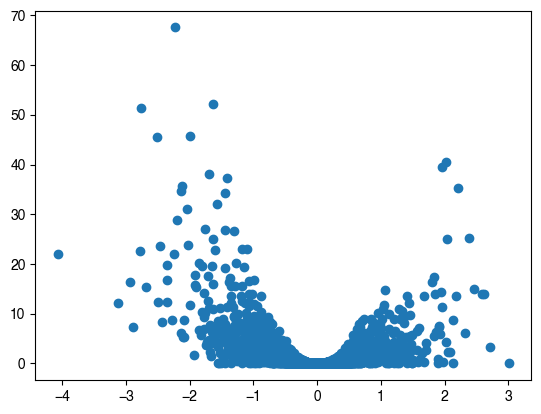

In [6]:
plt.scatter(df2['log2FoldChange'], -np.log10(df2['padj']))


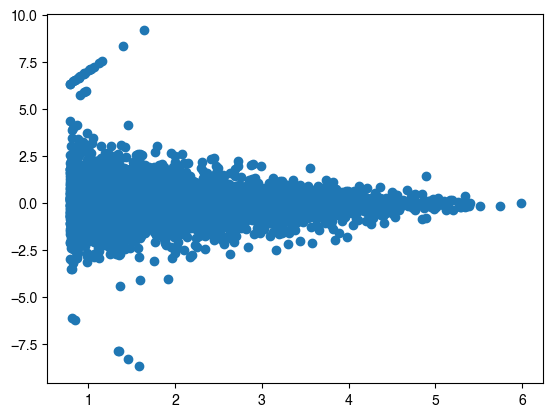

In [7]:
df = pd.read_csv('../../source_data/11_rnaseq_data_deseq2/L156F_no_drug_vs_NT_no_drug.csv').rename(columns={'Unnamed: 0':'gene_id'})


df['gene_name'] = [gene_name_dict[i] for i in df['gene_id']]


df = df.dropna()
plt.scatter(np.log10(df['baseMean']),df['log2FoldChange'])


In [8]:
df[(df['padj']<=.01) & (df['baseMean']>=50) & (df['log2FoldChange']<=-1)].sort_values(by='log2FoldChange', ascending=True)[50:100]

,gene_id,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene_name
6324,ENSG00000134198.10,62.512756,-1.673378,0.440021,-3.802954,1.429807e-04,4.447279e-03,TSPAN2
18746,ENSG00000230479.2,61.148745,-1.659447,0.346598,-4.787809,1.686121e-06,9.346353e-05,LNCTSI
16774,ENSG00000215481.10,124.119860,-1.656239,0.282063,-5.871879,4.308840e-09,4.052025e-07,BCRP3
12041,ENSG00000172602.11,815.880453,-1.646578,0.166696,-9.877703,5.201144e-23,2.808915e-20,RND1
1850,ENSG00000091986.16,7845.887075,-1.640915,0.103159,-15.906610,5.701816e-57,5.388786e-53,CCDC80
2301,ENSG00000101076.20,2049.042026,-1.637046,0.147022,-11.134670,8.505957e-29,7.656171e-26,HNF4A
11366,ENSG00000168955.4,1711.435937,-1.632441,0.217860,-7.493086,6.727259e-14,1.382159e-11,TM4SF20
8511,ENSG00000149564.12,270.795688,-1.630119,0.181407,-8.985956,2.564944e-19,1.010054e-16,ESAM
27103,ENSG00000277268.3,108.924964,-1.623530,0.290924,-5.580607,2.396810e-08,1.961234e-06,LHX1-DT
31110,ENSG00000293925.1,88.949306,-1.609334,0.294800,-5.459065,4.786472e-08,3.723206e-06,ENSG00000293925


In [163]:
df[df['gene_name']=='MYC']

,gene_id,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene_name
6822,ENSG00000136997.22,5949.488122,0.127671,0.138767,0.920043,0.35755,0.838594,MYC


# GSEA

In [9]:
import gseapy as gs

In [263]:
ranking

,stat
263,42.918354
30519,42.833000
5283,42.029561
9672,38.947105
3278,38.047522
...,...
15252,-31.832521
3309,-32.862023
2370,-36.939526
10777,-38.382564


In [10]:
df = pd.read_csv('../../source_data/11_rnaseq_data_deseq2/L156F_no_drug_vs_NT_no_drug.csv').rename(columns={'Unnamed: 0':'gene_id'})
df['gene_name'] = [gene_name_dict[i] for i in df['gene_id']]



df2 = df[df['baseMean']>=50]

df2 = df2.set_index('gene_name')

In [436]:
# Prepare the input: the GSEA input expects a series with gene names as the index and log2FoldChange as the values
ranking = df2[["stat"]]
ranking = ranking.sort_values("stat", ascending=False)
ranking

# Run pre-ranked GSEA
pre_res = gs.prerank(
    rnk=ranking,
    gene_sets='KEGG_2021_Human',  # or "GO_Biological_Process_2018", etc.'KEGG_2021_Human'
    outdir="gsea_output",   # output directory
    permutation_num=100,    # reduce for speed, increase for publication
    seed=42
)


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know

In [437]:
a = pre_res.res2d

b = a[a['FDR q-val']<.25]

b[:20]

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,Adherens junction,-0.563241,-2.03265,0.0,0.010952,0.01,26/61,17.28%,TGFBR1;TCF7;CDH1;TCF7L1;EGFR;VCL;TJP1;TCF7L2;S...
1,prerank,ECM-receptor interaction,-0.622077,-2.013058,0.0,0.010952,0.02,22/51,8.67%,COL4A1;COL4A2;LAMC2;FN1;NPNT;ITGB6;ITGA11;COL4...
2,prerank,Focal adhesion,-0.497291,-1.916495,0.0,0.014603,0.04,43/148,9.78%,COL4A1;COL4A2;MYL9;LAMC2;FN1;ITGB6;ITGA11;FLNC...
3,prerank,Tight junction,-0.484618,-1.894268,0.0,0.01369,0.05,42/125,17.29%,CLDN2;MYL9;TUBA4A;RDX;MSN;ARHGEF18;CGNL1;RUNX1...
4,prerank,Cell adhesion molecules,-0.51562,-1.784977,0.0,0.04819,0.2,17/63,10.87%,VCAN;CLDN2;CDH4;ESAM;NRXN3;CDH2;CDH1;CADM1;SDC...
5,prerank,Protein digestion and absorption,-0.635435,-1.777461,0.0,0.049285,0.23,15/40,5.05%,COL5A1;COL4A1;SLC7A7;COL4A2;FXYD2;COL7A1;COL4A...
7,prerank,PI3K-Akt signaling pathway,-0.409894,-1.672456,0.0,0.129862,0.43,44/221,9.04%,COL4A1;COL4A2;ERBB3;BCL2L11;LAMC2;FN1;ITGB6;FG...
9,prerank,Human papillomavirus infection,-0.408747,-1.63729,0.0,0.168391,0.55,83/248,19.45%,COL4A1;COL4A2;JAG1;LAMC2;FN1;ITGB6;ITGA11;TCF7...
10,prerank,IL-17 signaling pathway,0.451166,1.637116,0.0,0.225414,0.44,12/58,7.03%,PTGS2;CXCL3;MUC5AC;CXCL5;CXCL1;LCN2;CXCL8;FOSL...
11,prerank,Arrhythmogenic right ventricular cardiomyopathy,-0.503416,-1.636616,0.016667,0.149681,0.55,21/49,11.57%,CDH2;ITGB6;ITGA11;TCF7;TCF7L1;PKP2;ITGB4;CACNB...


In [323]:
a = pre_res.res2d

b = a[a['FDR q-val']<.25]
b
#.sort_values(by='NES')[:20]
pi3k = b[b['Term']=='PI3K-Akt signaling pathway']['Lead_genes'].values[0]
associated_genes = pi3k.split(';')

associated_genes

['COL4A1',
 'COL4A2',
 'ERBB3',
 'BCL2L11',
 'LAMC2',
 'FN1',
 'ITGB6',
 'FGFR4',
 'PHLPP1',
 'ITGA11',
 'COL4A3',
 'PDGFB',
 'SGK1',
 'THBS1',
 'COL1A1',
 'PIK3AP1',
 'IL4R',
 'COL4A4',
 'CREB3L2',
 'COL6A1',
 'EGFR',
 'ITGB4',
 'PDGFA',
 'EFNA1',
 'EFNA2',
 'ITGAV',
 'SGK2',
 'COL6A2',
 'MAGI1',
 'ITGA5',
 'GNB4',
 'PHLPP2',
 'GNG4',
 'PIK3CD',
 'LAMA5',
 'LAMB3',
 'CREB1',
 'IGF1R',
 'GSK3B',
 'VEGFA',
 'NFKB1',
 'ITGA4',
 'LPAR2',
 'AKT3']

# GSEA with MSigDB

In [11]:
samp_dict = {'L156F_24hrs_vs_L156F_no_drug':'../../source_data/11_rnaseq_data_deseq2/L156F_24hours_vs_L156F_no_drug.csv',
'L156F_48hrs_vs_L156F_no_drug':'../../source_data/11_rnaseq_data_deseq2/L156F_48hours_vs_L156F_no_drug.csv',
'NT_24hrs_vs_NT_no_drug':'../../source_data/11_rnaseq_data_deseq2/NT_24hours_vs_NT_no_drug.csv',
'NT_48hrs_vs_NT_no_drug':'../../source_data/11_rnaseq_data_deseq2/NT_48hours_vs_NT_no_drug.csv',
'L156F_no_drug_vs_NT_no_drug':'../../source_data/11_rnaseq_data_deseq2/L156F_no_drug_vs_NT_no_drug.csv'}

samples = list(samp_dict.keys())

tx2gene = pd.read_csv("../../source_data/11_rnaseq_data_deseq2/tx2gene.tsv", sep='\t')
gene_name_dict = dict(zip(tx2gene['gene_id'], tx2gene['gene_name']))

filtered_holder = []
unfiltered_holder = []

basemean_cutoff = 20

for i in samples:

    file = samp_dict[i]
    df = pd.read_csv(file).rename(columns={'Unnamed: 0':'gene_id'})
    df['gene_name'] = [gene_name_dict[i] for i in df['gene_id']]

    df2 = df[df['baseMean']>=basemean_cutoff]
    df2 = df2.set_index('gene_name')

    print(f'{len(df2)}/{len(df)}')

    filtered_holder.append(df2)
    unfiltered_holder.append(df)

filtered_dict = dict(zip(samples, filtered_holder))
unfiltered_dict = dict(zip(samples, unfiltered_holder))

15737/35965
15794/36094
16097/38233
15975/37525
15672/35867


In [12]:
aa = filtered_dict['NT_24hrs_vs_NT_no_drug'].reset_index()
aa[aa['gene_name']=='CDK9']

,gene_name,gene_id,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
5614,CDK9,ENSG00000136807.14,1944.945496,0.3125,0.083731,3.732184,0.00019,0.000893


In [569]:
msig.list_category(dbver="2024.1.Hs")

['c1.all',
 'c2.all',
 'c2.cgp',
 'c2.cp.biocarta',
 'c2.cp.kegg_legacy',
 'c2.cp.kegg_medicus',
 'c2.cp.pid',
 'c2.cp.reactome',
 'c2.cp',
 'c2.cp.wikipathways',
 'c3.all',
 'c3.mir.mir_legacy',
 'c3.mir.mirdb',
 'c3.mir',
 'c3.tft.gtrd',
 'c3.tft.tft_legacy',
 'c3.tft',
 'c4.3ca',
 'c4.all',
 'c4.cgn',
 'c4.cm',
 'c5.all',
 'c5.go.bp',
 'c5.go.cc',
 'c5.go.mf',
 'c5.go',
 'c5.hpo',
 'c6.all',
 'c7.all',
 'c7.immunesigdb',
 'c7.vax',
 'c8.all',
 'h.all',
 'msigdb']

In [29]:
from gseapy import Msigdb

msig = Msigdb()
#msig.list_dbver()

#msig.list_category(dbver="2024.1.Hs") 

gmt = msig.get_gmt(category='h.all', dbver="2024.1.Hs") #hallmarks

#trying the canonical pathways
#gmt = msig.get_gmt(category='c2.cp', dbver="2024.1.Hs") #canonical pathways

#gmt = msig.get_gmt(category='c2.cp.kegg_legacy', dbver="2024.1.Hs") #kegg legacy
#could try chemical and genetic perturbations
#gmt = msig.get_gmt(category='c2.cgp', dbver="2024.1.Hs") #hchemical and genetic perturbations


#gmt = msig.get_gmt(category='c6.all', dbver="2024.1.Hs") #oncogenic gene sets


#c2.cp.wikipathways
#gmt =  msig.get_gmt(category='c2.all', dbver="2024.1.Hs") 

# Prepare the input: the GSEA input expects a series with gene names as the index and log2FoldChange as the values
gsea_results = []
for samp in samples:
    df2 = filtered_dict[samp]

    ranking = df2[["stat"]]
    ranking = ranking.sort_values("stat", ascending=False)


    # Run pre-ranked GSEA
    pre_res2 = gs.prerank(
        rnk=ranking,
        gene_sets=gmt,  # or "GO_Biological_Process_2018", etc.'KEGG_2021_Human'
        outdir="gsea_output",   # output directory
        permutation_num=100,    # reduce for speed, increase for publication
        seed=42
    )

    gsea_results.append(pre_res2.res2d)

gsea_dict = dict(zip(samples, gsea_results))

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know

In [30]:
options = ['L156F_24hrs_vs_L156F_no_drug',
 'L156F_48hrs_vs_L156F_no_drug',
 'NT_24hrs_vs_NT_no_drug',
 'NT_48hrs_vs_NT_no_drug',
 'L156F_no_drug_vs_NT_no_drug']

a1 = gsea_dict['L156F_no_drug_vs_NT_no_drug']

a1[:40]

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION,-0.556827,-2.155317,0.0,0.0,0.0,59/159,8.51%,COL5A1;TAGLN;VCAN;COL4A1;MATN2;TPM1;COL4A2;SER...
1,prerank,HALLMARK_TGF_BETA_SIGNALING,-0.656969,-2.059114,0.0,0.0,0.0,19/51,9.25%,SERPINE1;TGFBR1;SMAD7;PMEPA1;LTBP2;JUNB;SPTBN1...
2,prerank,HALLMARK_APICAL_JUNCTION,-0.506918,-2.016913,0.0,0.0,0.0,64/155,18.97%,VCAN;CDH4;TGFBI;SPEG;MYL9;LAMC2;EPB41L2;MSN;FL...
3,prerank,HALLMARK_HYPOXIA,-0.480691,-1.930031,0.0,0.0,0.0,54/171,11.43%,COL5A1;SERPINE1;ACKR3;VLDLR;TGFBI;CCN2;TES;IGF...
4,prerank,HALLMARK_COAGULATION,-0.48921,-1.802988,0.0,0.001886,0.01,33/89,10.49%,HNF4A;SERPINE1;F2;FN1;SPARC;KLF7;PDGFB;TIMP3;T...
5,prerank,HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY,0.499789,1.772959,0.0,0.010837,0.01,14/46,12.80%,GCLC;SRXN1;TXNRD1;GSR;TXN;NQO1;GCLM;MBP;GPX4;P...
6,prerank,HALLMARK_MITOTIC_SPINDLE,-0.430214,-1.726721,0.0,0.003143,0.02,55/198,16.36%,TUBA4A;BCL2L11;TRIO;EPB41L2;FGD4;DOCK2;SPTBN1;...
7,prerank,HALLMARK_COMPLEMENT,-0.42567,-1.663329,0.0,0.009428,0.06,40/147,12.31%,HNF4A;COL4A2;SERPINE1;CDA;RASGRP1;F2;FN1;PDGFB...
8,prerank,HALLMARK_MYOGENESIS,-0.424825,-1.644024,0.0,0.010606,0.08,31/129,10.32%,TAGLN;COL4A2;SPEG;ERBB3;NAV2;PDLIM7;IGFBP7;SPA...
9,prerank,HALLMARK_INFLAMMATORY_RESPONSE,0.382181,1.604397,0.0,0.037931,0.06,27/117,6.34%,KCNJ2;ADORA2B;CSF1;LPAR1;NAMPT;TACR1;CDKN1A;TN...


In [17]:
a1[a1['Term']=='REACTOME_G1_S_DNA_DAMAGE_CHECKPOINTS']

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes


<Axes: xlabel='NES', ylabel='Term'>

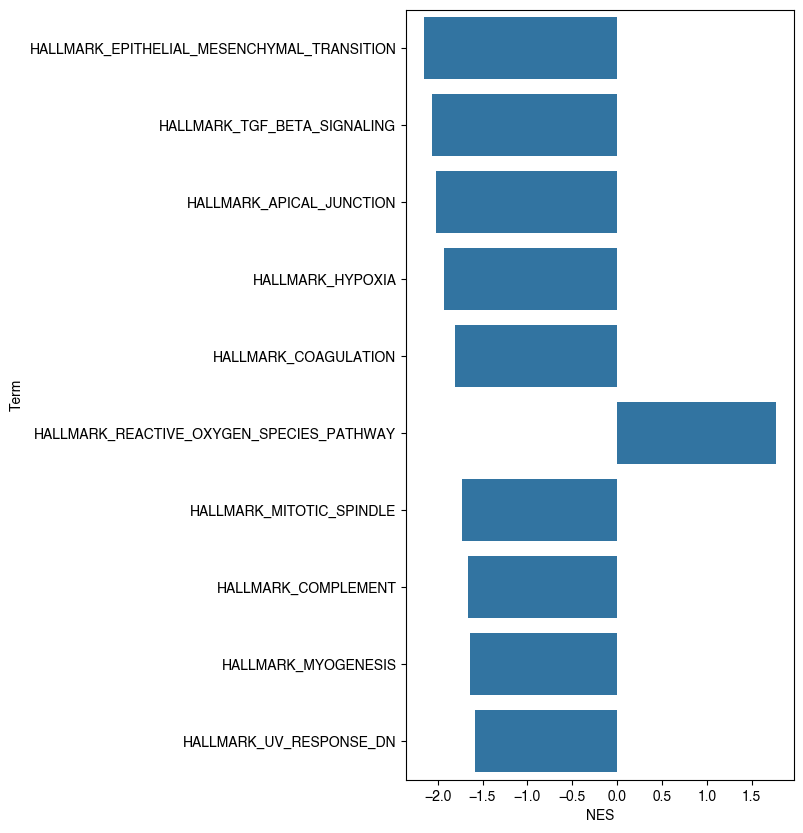

In [31]:
plt.figure(figsize=(5,10
                    ))
sns.barplot(data = a1[a1['FDR q-val']<.02][:20], x='NES', y='Term')

<Axes: xlabel='NES', ylabel='Term'>

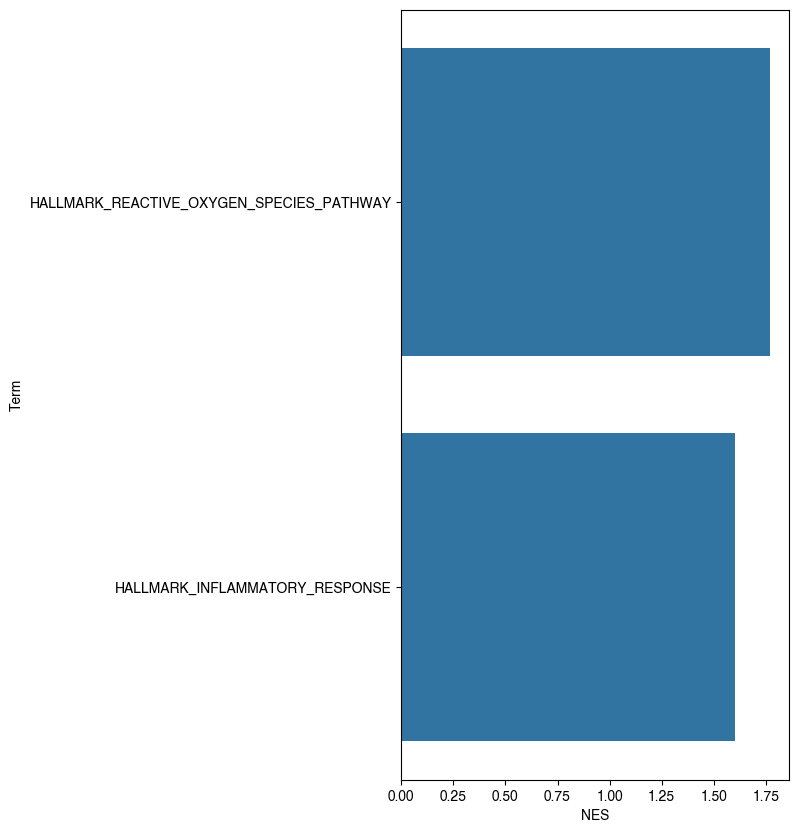

In [32]:
plt.figure(figsize=(5,10
                    ))
sns.barplot(data = a1[(a1['FDR q-val']<.1) & (a1['NES']>0)][:20], x='NES', y='Term')

In [662]:
a1[a1['Term']=='SWEET_KRAS_ONCOGENIC_SIGNATURE']

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
2051,prerank,SWEET_KRAS_ONCOGENIC_SIGNATURE,-0.254371,-0.950773,0.533333,0.659643,1.0,16/77,16.70%,TGFBI;NPC2;MT2A;ID2;SIRPA;RO60;ACLY;HNF1B;HIF1...


In [588]:
gmt = msig.get_gmt(category='c2.cp', dbver="2024.1.Hs")

In [25]:


sample_names = ['L156F: 100 nM PROTAC 24 hours\nvs. No Drug',
                'L156F: 100 nM PROTAC 48 hours\nvs. No Drug',
                'NT gRNA: 100 nM PROTAC 24 hours\nvs. No Drug',
                'NT gRNA: 100 nM PROTAC 48 hours\nvs. No Drug',
                'L156F vs. NT gRNA (No Drug)']

samp_name_dict = dict(zip(samples, sample_names))
samp_name_dict

{'L156F_24hrs_vs_L156F_no_drug': 'L156F: 100 nM PROTAC 24 hours\nvs. No Drug',
 'L156F_48hrs_vs_L156F_no_drug': 'L156F: 100 nM PROTAC 48 hours\nvs. No Drug',
 'NT_24hrs_vs_NT_no_drug': 'NT gRNA: 100 nM PROTAC 24 hours\nvs. No Drug',
 'NT_48hrs_vs_NT_no_drug': 'NT gRNA: 100 nM PROTAC 48 hours\nvs. No Drug',
 'L156F_no_drug_vs_NT_no_drug': 'L156F vs. NT gRNA (No Drug)'}

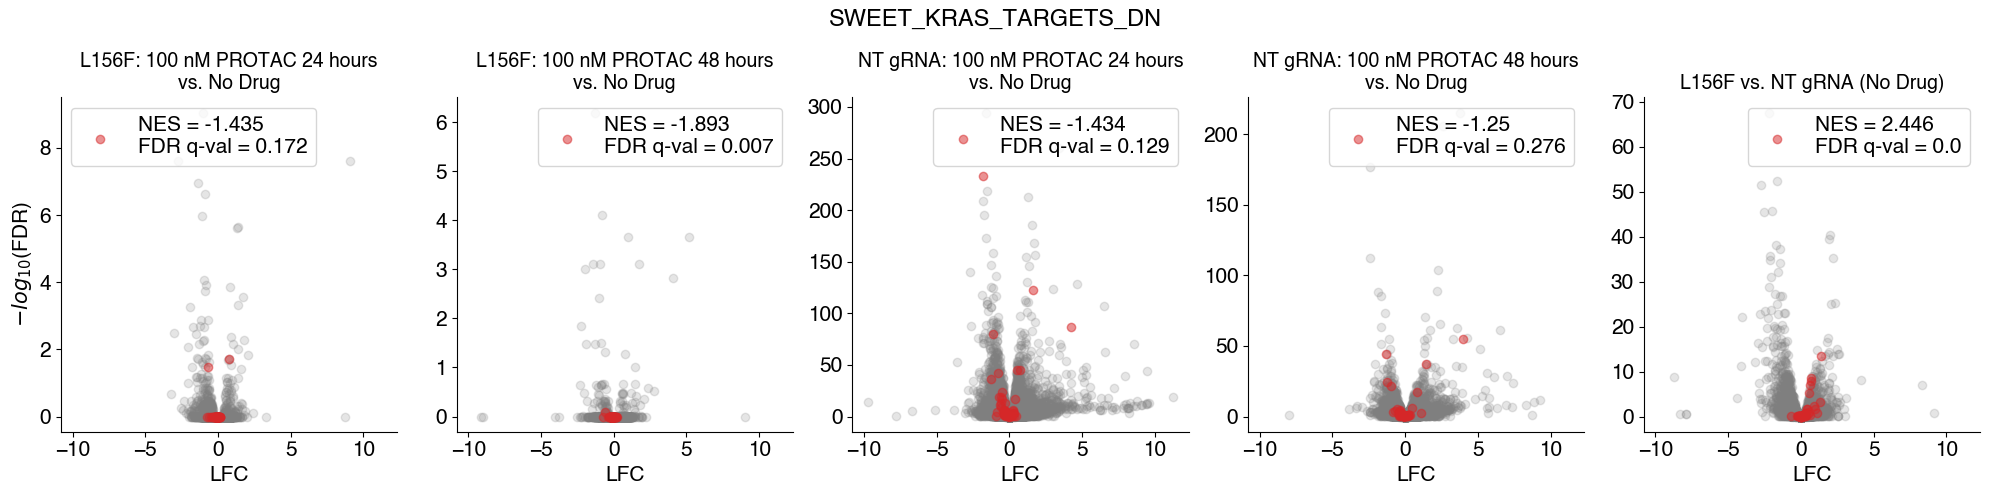

In [27]:
fig, ax = plt.subplots(1,5, figsize=(20,5), sharey=False, sharex=True)

term = 'SWEET_KRAS_TARGETS_DN'
associated_genes = gmt[term]

for i in range(5):
    ax[i].spines[['top', 'right']].set_visible(False)
    ax[i].tick_params(axis='x', which='major', labelsize=15)
    ax[i].tick_params(axis='y', which='major', labelsize=15)
    ax[i].set_xlabel('LFC', fontsize=15)

ax[0].set_ylabel('$-log_{10}$(FDR)', fontsize=15)

for i, k in enumerate(samples):
    a = filtered_dict[k].reset_index()
    
    subset1 = a[a['gene_name'].isin(associated_genes)]
    other = a[~a['gene_name'].isin(associated_genes)]

    g_out = gsea_dict[k]
    
    NES  = np.round(g_out.loc[g_out['Term']==term, 'NES'].values[0],3)
    fdr_q = np.round(g_out.loc[g_out['Term']==term, 'FDR q-val'].values[0], 3)
    
    ax[i].scatter(other['log2FoldChange'], -np.log10(other['padj']), color='tab:grey', alpha=.2)
    ax[i].scatter(subset1['log2FoldChange'], -np.log10(subset1['padj']), color='tab:red', label=f'NES = {NES}\nFDR q-val = {fdr_q}', alpha=.5)
    ax[i].legend(fontsize=15)

    ax[i].set_title(samp_name_dict[k], fontsize=14)

    

fig.suptitle(term, fontsize=17)
fig.tight_layout()


In [640]:
samples

['L156F_24hrs_vs_L156F_no_drug',
 'L156F_48hrs_vs_L156F_no_drug',
 'NT_24hrs_vs_NT_no_drug',
 'NT_48hrs_vs_NT_no_drug',
 'L156F_no_drug_vs_NT_no_drug']

In [643]:
k = 'L156F_no_drug_vs_NT_no_drug'
a = filtered_dict[k].reset_index()
    
subset1 = a[a['gene_name'].isin(associated_genes)]
other = a[~a['gene_name'].isin(associated_genes)]
subset1.sort_values(by='padj')[:20
                               ]

,gene_name,gene_id,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
1167,TNS1,ENSG00000079308.21,1999.362624,-2.222871,0.123384,-18.015855,1.463041e-72,2.765440e-68
4811,COL5A1,ENSG00000130635.17,6904.394173,-1.987472,0.133448,-14.893224,3.647500e-50,1.723626e-46
6958,TAGLN,ENSG00000149591.17,1441.438764,-2.513226,0.169343,-14.841049,7.950253e-50,3.005513e-46
12338,LBH,ENSG00000213626.13,6649.578536,-1.419740,0.105425,-13.466828,2.451740e-41,5.149199e-38
11216,COL4A1,ENSG00000187498.17,3797.642752,-2.140666,0.164579,-13.006933,1.117371e-38,1.760046e-35
5045,MATN2,ENSG00000132561.14,1790.717693,-1.438885,0.125142,-11.497980,1.350393e-30,1.418063e-27
6041,TPM1,ENSG00000140416.26,25582.480108,-1.100177,0.102862,-10.695696,1.066157e-26,8.061000e-24
3308,HGD,ENSG00000113924.12,2203.717522,-1.277239,0.127036,-10.054128,8.809792e-24,5.371700e-21
5287,COL4A2,ENSG00000134871.20,9553.172141,-1.854633,0.184990,-10.025589,1.176561e-23,6.949799e-21
10362,CDH4,ENSG00000179242.16,697.543991,-2.351023,0.236598,-9.936767,2.880231e-23,1.649761e-20


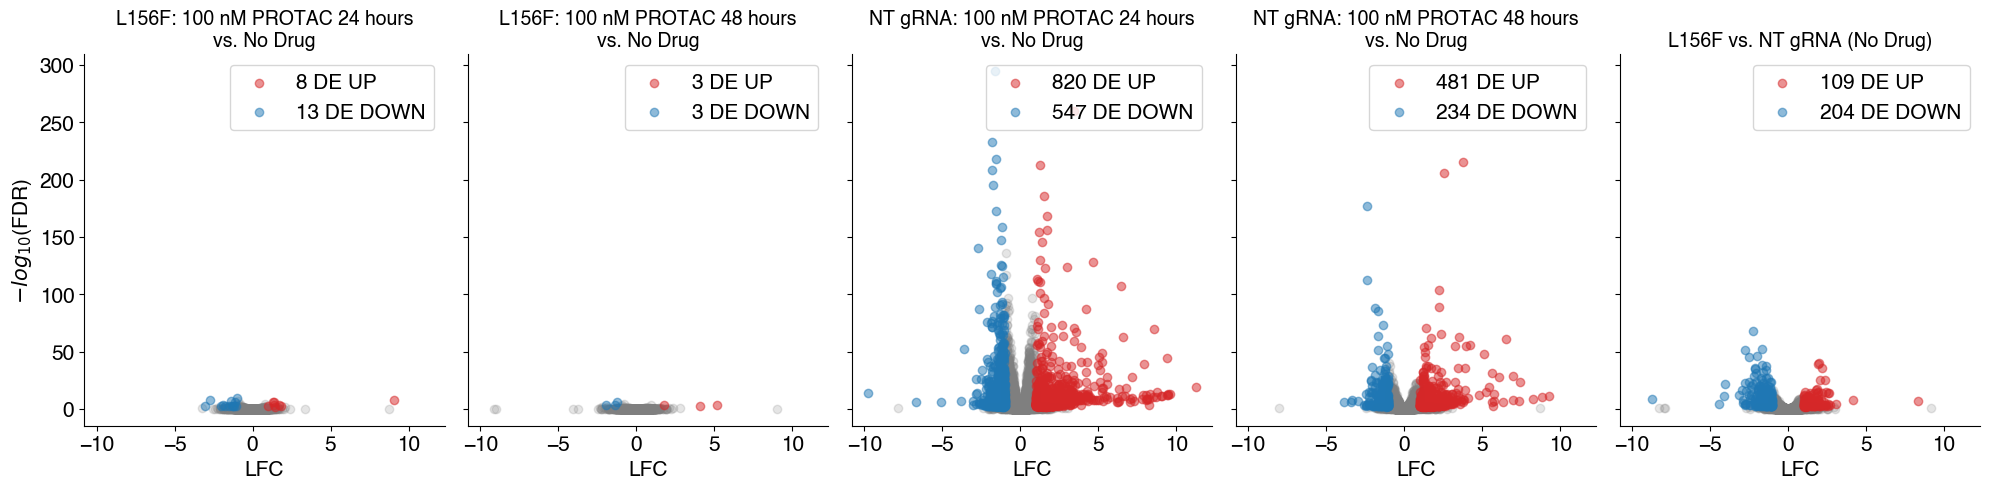

In [632]:
fig, ax = plt.subplots(1,5, figsize=(20,5), sharey=True, sharex=True)

term = 'REACTOME_MAP2K_AND_MAPK_ACTIVATION'
associated_genes = gmt[term]

for i in range(5):
    ax[i].spines[['top', 'right']].set_visible(False)
    ax[i].tick_params(axis='x', which='major', labelsize=15)
    ax[i].tick_params(axis='y', which='major', labelsize=15)
    ax[i].set_xlabel('LFC', fontsize=15)

ax[0].set_ylabel('$-log_{10}$(FDR)', fontsize=15)

for i, k in enumerate(samples):
    a = filtered_dict[k].reset_index()
    subset_low = a[(a['log2FoldChange']<=-1) & (a['padj']<=.01)]
    #subset_high = a[a['gene_name'].isin(associated_genes)]
    subset_high = a[(a['log2FoldChange']>=1) & (a['padj']<=.01)]

    idx_de = pd.concat((subset_low, subset_high))

    a_no_change = a.drop(list(idx_de.index), axis=0)
    
    
    ax[i].scatter(a_no_change['log2FoldChange'], -np.log10(a_no_change['padj']), color='tab:grey', alpha=.2)
    ax[i].scatter(subset_high['log2FoldChange'], -np.log10(subset_high['padj']), color='tab:red', label=f'{len(subset_high)} DE UP', alpha=.5)
    ax[i].scatter(subset_low['log2FoldChange'], -np.log10(subset_low['padj']), color='tab:blue', label=f'{len(subset_low)} DE DOWN', alpha=.5)

    ax[i].legend(fontsize=15)

    ax[i].set_title(samp_name_dict[k], fontsize=14)

    
fig.tight_layout()

In [652]:
samples

['L156F_24hrs_vs_L156F_no_drug',
 'L156F_48hrs_vs_L156F_no_drug',
 'NT_24hrs_vs_NT_no_drug',
 'NT_48hrs_vs_NT_no_drug',
 'L156F_no_drug_vs_NT_no_drug']

In [656]:
a = filtered_dict['NT_24hrs_vs_NT_no_drug'].reset_index()

b = filtered_dict['NT_48hrs_vs_NT_no_drug'].reset_index()

subset_low_24 = a[(a['log2FoldChange']<=-1) & (a['padj']<=.01)]
#subset_high = a[a['gene_name'].isin(associated_genes)]
subset_high_24 = a[(a['log2FoldChange']>=1) & (a['padj']<=.01)]

subset_low_48 = b[(b['log2FoldChange']<=-1) & (b['padj']<=.01)]
#subset_high = a[a['gene_name'].isin(associated_genes)]
subset_high_48 = b[(b['log2FoldChange']>=1) & (b['padj']<=.01)]


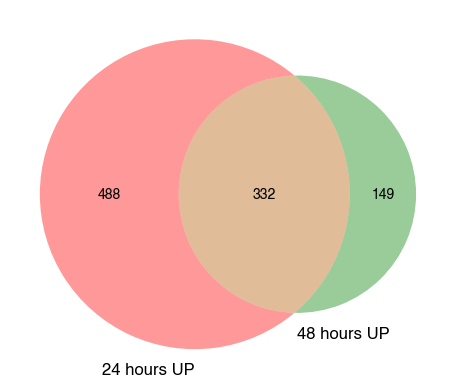

In [657]:
from matplotlib_venn import venn2

list1 = list(subset_high_24['gene_name'])
list2 = list(subset_high_48['gene_name'])

venn2([set(list1), set(list2)], set_labels=('24 hours UP', '48 hours UP'))

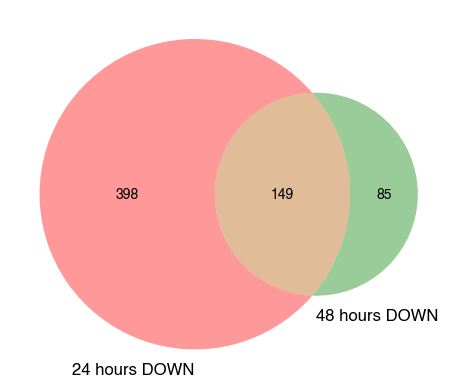

In [658]:
list1 = list(subset_low_24['gene_name'])
list2 = list(subset_low_48['gene_name'])

venn2([set(list1), set(list2)], set_labels=('24 hours DOWN', '48 hours DOWN'))

In [629]:
k = 'L156F_48hrs_vs_L156F_no_drug'
a = filtered_dict[k].reset_index()
a[a['padj']<.01]

,gene_name,gene_id,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
217,NME1-NME2,ENSG00000011052.21,395.523809,0.964664,0.174335,5.533408,3.140681e-08,2.175199e-04
290,RGPD5,ENSG00000015568.13,218.888461,1.752475,0.335991,5.215831,1.829949e-07,7.608788e-04
1476,CHGB,ENSG00000089199.10,954.302309,-0.828263,0.142126,-5.827646,5.621450e-09,7.743547e-05
1905,BDKRB1,ENSG00000100739.11,216.492565,-0.998174,0.208462,-4.788272,1.682233e-06,3.862127e-03
4003,EGR1,ENSG00000120738.8,120.109982,-1.398671,0.268760,-5.204170,1.948656e-07,7.608788e-04
5801,RBP4,ENSG00000138207.15,528.681076,-0.948417,0.183064,-5.180793,2.209448e-07,7.608788e-04
12500,MUC5AC,ENSG00000215182.8,2325.484085,-1.254484,0.187666,-6.684670,2.314452e-11,6.376316e-07
12973,GOLGA8N,ENSG00000232653.9,88.621222,-1.979567,0.387294,-5.111274,3.199940e-07,9.795371e-04
12976,GTF2I-AS1,ENSG00000232729.9,54.615185,4.072053,0.815134,4.995566,5.866353e-07,1.469255e-03
14550,ENSG00000273711,ENSG00000273711.2,24.792720,5.167415,0.934022,5.532433,3.158184e-08,2.175199e-04


In [621]:
a = filtered_dict[k].reset_index()
subset_low = a[(a['log2FoldChange']<=-1) & (a['padj']<=.01)]
#subset_high = a[a['gene_name'].isin(associated_genes)]
subset_high = a[(a['log2FoldChange']>=1) & (a['padj']<=.01)]

idx_de = pd.concat((subset_low, subset_high))

a_no_change = a.drop(list(idx_de.index), axis=0)

,gene_name,gene_id,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,TSPAN6,ENSG00000000003.16,1422.589780,-0.019971,0.259572,-0.076938,0.938673,0.995481
1,DPM1,ENSG00000000419.14,1348.009095,0.315192,0.223984,1.407207,0.159366,0.629373
2,SCYL3,ENSG00000000457.14,305.355630,0.267467,0.221097,1.209729,0.226383,0.725928
3,FIRRM,ENSG00000000460.17,693.240995,0.075808,0.226179,0.335168,0.737498,0.970244
4,CFH,ENSG00000000971.17,3683.131192,-0.094347,0.185759,-0.507900,0.611523,0.944969
...,...,...,...,...,...,...,...,...
15667,ENSG00000310534,ENSG00000310534.1,23.451927,0.365768,0.749690,0.487892,0.625626,0.948693
15668,ENSG00000310535,ENSG00000310535.1,63.493342,0.516733,0.321945,1.605037,0.108486,0.526400
15669,ENSG00000310536,ENSG00000310536.1,26.716057,-0.454655,0.455564,-0.998005,0.318277,0.809809
15670,ENSG00000310537,ENSG00000310537.1,88.229341,0.151018,0.320415,0.471319,0.637413,0.951482


In [622]:
a

,gene_name,gene_id,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,TSPAN6,ENSG00000000003.16,1422.589780,-0.019971,0.259572,-0.076938,0.938673,0.995481
1,DPM1,ENSG00000000419.14,1348.009095,0.315192,0.223984,1.407207,0.159366,0.629373
2,SCYL3,ENSG00000000457.14,305.355630,0.267467,0.221097,1.209729,0.226383,0.725928
3,FIRRM,ENSG00000000460.17,693.240995,0.075808,0.226179,0.335168,0.737498,0.970244
4,CFH,ENSG00000000971.17,3683.131192,-0.094347,0.185759,-0.507900,0.611523,0.944969
...,...,...,...,...,...,...,...,...
15667,ENSG00000310534,ENSG00000310534.1,23.451927,0.365768,0.749690,0.487892,0.625626,0.948693
15668,ENSG00000310535,ENSG00000310535.1,63.493342,0.516733,0.321945,1.605037,0.108486,0.526400
15669,ENSG00000310536,ENSG00000310536.1,26.716057,-0.454655,0.455564,-0.998005,0.318277,0.809809
15670,ENSG00000310537,ENSG00000310537.1,88.229341,0.151018,0.320415,0.471319,0.637413,0.951482


In [692]:
gmt = msig.get_gmt(category='c6.all', dbver="2024.1.Hs") #oncogenic gene sets

s = 'L156F_no_drug_vs_NT_no_drug'
aa = gsea_dict[s]

term = 'KRAS.600_UP.V1_UP'
associated_genes = gmt[term]

a = filtered_dict[s].reset_index()
    
subset1 = a[a['gene_name'].isin(associated_genes)]
subset1.sort_values(by='log2FoldChange')[:20]

,gene_name,gene_id,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
118,USH1C,ENSG00000006611.17,428.185925,-2.757662,0.175085,-15.750429,6.821644e-56,4.298090e-52
5367,RDH5,ENSG00000135437.10,79.667411,-1.822172,0.324775,-5.610566,2.016658e-08,1.671880e-06
2972,KIAA1549L,ENSG00000110427.17,412.717621,-1.807473,0.182586,-9.899315,4.191375e-23,2.330158e-20
2902,TRIM2,ENSG00000109654.16,69.079268,-1.400726,0.387667,-3.613221,3.024162e-04,8.308534e-03
6060,NTRK3,ENSG00000140538.17,6258.743416,-1.170762,0.109548,-10.687210,1.168324e-26,8.493714e-24
10278,GLDC,ENSG00000178445.10,1063.415314,-0.997645,0.127378,-7.832183,4.794713e-15,1.147211e-12
5317,ADAM19,ENSG00000135074.16,1050.664658,-0.953915,0.142315,-6.702852,2.043908e-11,2.861774e-09
9296,KCNAB3,ENSG00000170049.10,103.511851,-0.888279,0.270979,-3.278037,1.045318e-03,2.287806e-02
5794,RBP4,ENSG00000138207.15,983.072246,-0.865543,0.159200,-5.436837,5.423476e-08,4.175795e-06
11985,TGM2,ENSG00000198959.12,77819.463378,-0.801231,0.163865,-4.889592,1.010452e-06,5.913176e-05


In [578]:
a = filtered_dict[s].reset_index()

a[a['gene_name'].isin(['KRAS', 'NRAS', 'HRAS', 'TP53', 'CTNNB1', 'MYC', 'YAP'])]

,gene_name,gene_id,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
5204,KRAS,ENSG00000133703.14,1039.994172,-0.007209,0.107784,-0.066885,9.466730e-01,9.734854e-01
5663,MYC,ENSG00000136997.22,6774.314181,0.467043,0.046952,9.947327,2.590479e-23,9.218508e-22
6223,TP53,ENSG00000141510.19,4139.966583,0.322820,0.053057,6.084392,1.169345e-09,1.214469e-08
9101,CTNNB1,ENSG00000168036.19,8875.222729,-0.324209,0.043359,-7.477297,7.586690e-14,1.240499e-12
10013,HRAS,ENSG00000174775.18,3257.785193,0.752464,0.055351,13.594291,4.329363e-42,4.250074e-40
12476,NRAS,ENSG00000213281.5,1965.530517,0.045822,0.093183,0.491739,6.229035e-01,7.741952e-01


In [582]:
s = 'NT_24hrs_vs_NT_no_drug'

a = filtered_dict[s].reset_index()
a.sort_values(by='padj')[:20]

,gene_name,gene_id,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
8633,CLDN2,ENSG00000165376.12,3923.045245,-2.394273,0.062379,-38.382564,0.000000e+00,0.000000e+00
212,NME1-NME2,ENSG00000011052.21,1865.490852,4.276233,0.099636,42.918354,0.000000e+00,0.000000e+00
4350,CDKN1A,ENSG00000124762.15,15530.959923,1.833353,0.043621,42.029561,0.000000e+00,0.000000e+00
11303,HEXIM1,ENSG00000186834.4,4626.199499,-2.638123,0.052707,-50.052561,0.000000e+00,0.000000e+00
2735,ACTA2,ENSG00000107796.14,2785.775542,2.455542,0.064539,38.047522,0.000000e+00,0.000000e+00
15260,ENSG00000287001,ENSG00000287001.4,8621.834608,2.923651,0.068257,42.833000,0.000000e+00,0.000000e+00
7798,BTG2,ENSG00000159388.6,1810.260154,2.938985,0.075461,38.947105,0.000000e+00,0.000000e+00
1991,CDC25B,ENSG00000101224.18,9180.933622,-1.597237,0.043239,-36.939526,1.072798e-298,3.435904e-295
4019,EGR1,ENSG00000120738.8,1524.385219,3.431742,0.098866,34.710992,5.377929e-264,1.531037e-260
2762,DKK1,ENSG00000107984.10,7086.479573,-1.814699,0.055222,-32.862023,7.670286e-237,1.965281e-233


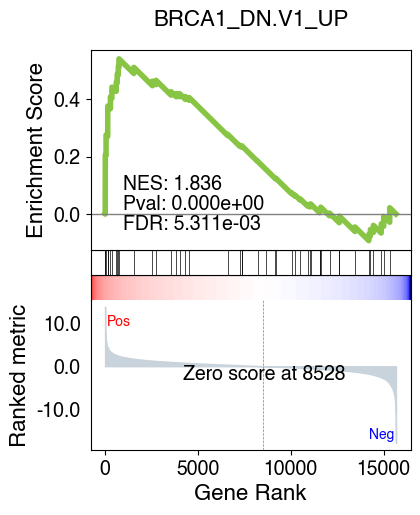

In [689]:
aa = gsea_dict['L156F_no_drug_vs_NT_no_drug']
axs = pre_res2.plot(terms=term)

In [564]:
from scipy.stats import zscore


tpm = pd.read_csv('rnaseq_data_deseq2/salmon.merged.gene_tpm.tsv', sep='\t')

subset1 = tpm[tpm['gene_name'].isin(associated_genes)]

replicates =  ['L156F_no_drug_1', 'L156F_no_drug_2','L156F_no_drug_3',
               'L156F_24hours_1', 'L156F_24hours_2','L156F_24hours_3', 
               'L156F_48hours_1', 'L156F_48hours_2','L156F_48hours_3', 
               'NT_no_drug_1','NT_no_drug_2', 'NT_no_drug_3',
                 'NT_24hours_1', 'NT_24hours_2', 'NT_24hours_3',
       'NT_48hours_1', 'NT_48hours_2', 'NT_48hours_3', ]


df_zscore_row = subset1[replicates].apply(zscore, axis=1)



<Axes: >

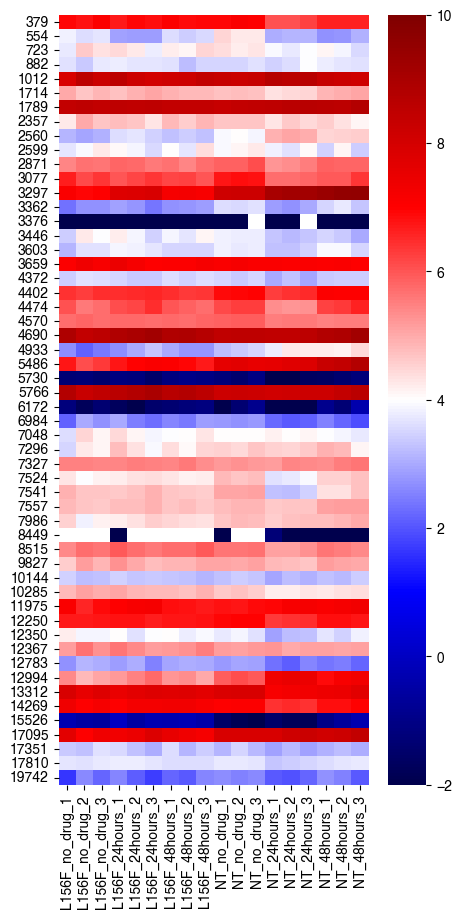

In [568]:
fig, ax = plt.subplots(figsize=(5,10))
sns.heatmap(np.log2(subset1[replicates]), cmap='seismic', vmin=-2, vmax=10)

In [567]:
np.log2(subset1[replicates])

,L156F_no_drug_1,L156F_no_drug_2,L156F_no_drug_3,L156F_24hours_1,L156F_24hours_2,L156F_24hours_3,L156F_48hours_1,L156F_48hours_2,L156F_48hours_3,NT_no_drug_1,NT_no_drug_2,NT_no_drug_3,NT_24hours_1,NT_24hours_2,NT_24hours_3,NT_48hours_1,NT_48hours_2,NT_48hours_3
379,6.943117,6.788004,7.079484,6.676783,6.934920,6.817374,7.054914,6.878526,6.942031,6.929375,7.116394,7.040286,6.050741,6.057698,6.217991,6.624788,6.588081,6.585319
554,3.828449,3.620065,3.681828,2.895240,2.857211,2.867022,3.621265,3.399660,3.533911,4.497988,4.275760,4.263827,3.043024,3.135860,3.147303,2.688318,2.747200,3.083166
723,3.754930,4.651272,4.362339,4.455842,4.261216,3.788492,4.231595,4.107997,4.487266,4.402337,4.200624,4.310860,3.944059,3.719316,3.962504,4.117906,3.864226,3.543507
882,3.670728,3.356222,3.745460,3.782917,3.697328,3.692015,3.637508,3.241645,3.504470,3.511139,3.524329,3.663852,3.462068,3.607062,3.987659,3.789373,3.698608,3.629946
1012,7.909525,8.590285,8.239711,8.586372,8.172012,8.056902,8.150172,8.194358,8.429320,8.331024,8.218992,8.345763,8.727251,8.605644,8.648832,8.356162,8.257636,8.125939
1714,5.008354,4.661805,4.843967,4.735744,4.903914,5.046971,4.897596,4.833068,4.814111,4.728480,4.754182,4.729926,4.373404,4.431498,4.489209,4.856998,4.945296,5.039094
1789,8.450433,8.519802,8.424092,8.545655,8.464548,8.504285,8.446871,8.421341,8.422733,8.353178,8.451407,8.460109,8.505956,8.632482,8.658549,8.611364,8.550531,8.747157
2357,4.243494,5.002644,4.701002,4.773013,4.667405,4.320372,4.830791,4.582267,4.881748,4.663765,4.663253,4.696525,4.311464,4.622132,4.453016,4.587045,4.349052,4.107769
2560,3.110804,2.957350,3.088240,3.620958,3.688934,3.472520,3.273790,3.410109,3.293228,3.918652,4.041716,3.890158,4.894615,5.057287,4.964810,4.514891,4.556887,4.597619
2599,3.701220,3.912718,4.241406,4.089996,3.860608,3.574955,4.043407,3.677927,4.398779,3.933388,4.113651,4.253002,3.853087,3.644165,4.088849,3.447019,4.109379,3.433914


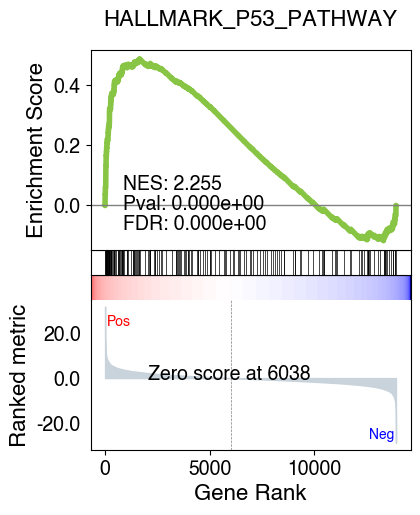

In [483]:


terms = pre_res2.res2d.Term
axs = pre_res2.plot(terms=terms[2]) # v1.0.5

In [484]:
term = 'HALLMARK_P53_PATHWAY'

pi3k = a2[a2['Term']==term]['Lead_genes'].values[0]
associated_genes = pi3k.split(';')

In [485]:
associated_genes = gmt[term]


In [486]:
#df = pd.read_csv('rnaseq_data_deseq2/L156F_no_drug_vs_NT_no_drug.csv').rename(columns={'Unnamed: 0':'gene_id'})

df = pd.read_csv(file).rename(columns={'Unnamed: 0':'gene_id'})
#df = pd.read_csv('rnaseq_data_deseq2/NT_24hours_vs_NT_no_drug.csv').rename(columns={'Unnamed: 0':'gene_id'})


df['gene_name'] = [gene_name_dict[i] for i in df['gene_id']]
df2 = df[df['baseMean']>=50]

In [487]:
subset1 = df2[df2['gene_name'].isin(associated_genes)]
other = df2[~df2['gene_name'].isin(associated_genes)]

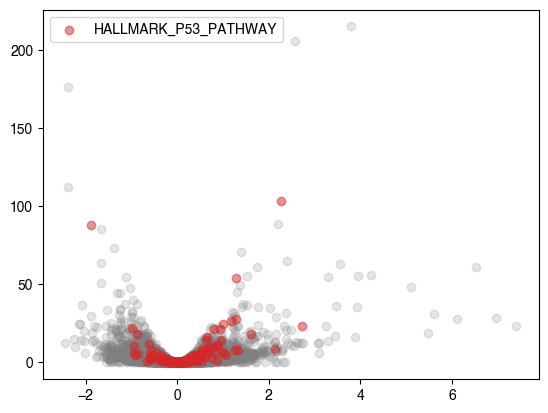

In [488]:
plt.scatter(other['log2FoldChange'], -np.log10(other['padj']), color='tab:grey', alpha=.2)
plt.scatter(subset1['log2FoldChange'], -np.log10(subset1['padj']), color='tab:red', label=term, alpha=.5)
plt.legend()


# PCA

Text(0.5, 0, 'PC1: 29% variance')

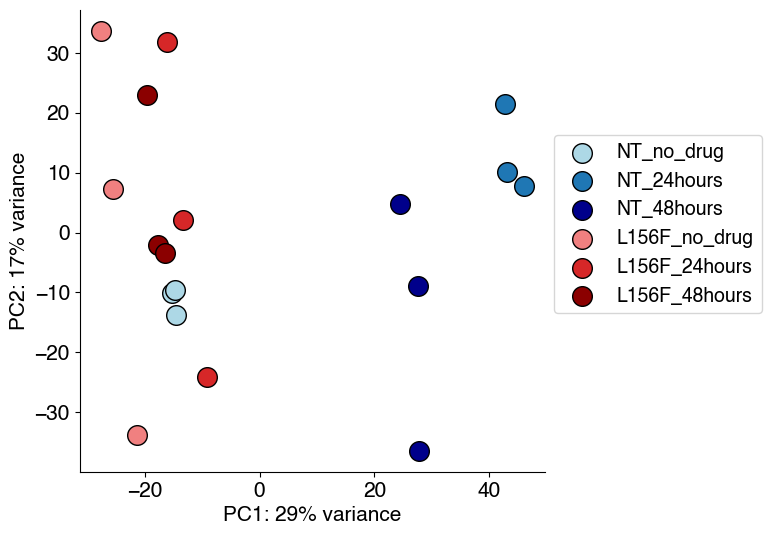

In [243]:
pca = pd.read_csv('rnaseq_data_deseq2/deseq2.pca.vals.txt', sep='\t')

pca['condition'] = [i[:-2] for i in pca['sample']]

samps = ['NT_no_drug','NT_24hours', 'NT_48hours', 'L156F_no_drug','L156F_24hours', 'L156F_48hours', ]
c_dict = {'L156F_24hours':'tab:red', 'L156F_48hours':'darkred', 'L156F_no_drug':'lightcoral', 'NT_24hours':'tab:blue', 'NT_48hours':'darkblue', 'NT_no_drug':'lightblue'}


fig, ax = plt.subplots(figsize=(6,6))
for i in samps:
    pca_subset = pca[pca['condition']==i]
    ax.scatter(pca_subset['PC1: 29% variance'], pca_subset['PC2: 17% variance'], label=i, c=c_dict[i], edgecolor='black', s=200)
ax.legend(bbox_to_anchor=(1,.75), fontsize=14)

ax.spines[['right', 'top']].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=15)
ax.set_ylabel('PC2: 17% variance', fontsize=15)
ax.set_xlabel('PC1: 29% variance', fontsize=15)

array(['L156F_24hours', 'L156F_48hours', 'L156F_no_drug', 'NT_24hours',
       'NT_48hours', 'NT_no_drug'], dtype=object)